# Predicting Rain Tomorrow — Train a Model & Deploy with Streamlit



## 1. Setup

In [3]:
import pandas as pd
import numpy as np
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

RANDOM_STATE = 42

## 2. Load & clean the data

Same cleaning as before: fill the few missing numeric values with the column median, and
label-encode the text columns (`Season`, `RainToday`, `RainTomorrow`) into numbers models can
use.

In [4]:
df = pd.read_excel(r"C:\Users\HP\Desktop\weather_dataset.xlsx")

num_cols = ["Humidity_pct", "WindSpeed_kmh", "Pressure_hPa"]
for c in num_cols:
    df[c] = df[c].fillna(df[c].median())

le_season = LabelEncoder()
le_raintoday = LabelEncoder()
le_target = LabelEncoder()

df["Season_enc"] = le_season.fit_transform(df["Season"])
df["RainToday_enc"] = le_raintoday.fit_transform(df["RainToday"])
df["RainTomorrow_enc"] = le_target.fit_transform(df["RainTomorrow"])

print("Season classes:     ", list(le_season.classes_))
print("RainToday classes:  ", list(le_raintoday.classes_))
print("RainTomorrow classes:", list(le_target.classes_))
df.head()

Season classes:      ['Autumn', 'Spring', 'Summer', 'Winter']
RainToday classes:   ['No', 'Yes']
RainTomorrow classes: ['No', 'Yes']


,Date,Season,MinTemp_C,MaxTemp_C,AvgTemp_C,Humidity_pct,Pressure_hPa,WindSpeed_kmh,CloudCover_pct,Precipitation_mm,RainToday,RainTomorrow,Season_enc,RainToday_enc,RainTomorrow_enc
0,2023-01-01,Winter,0.2,8.8,4.8,79.8,1010.1,2.0,30.2,10.4,Yes,Yes,3,1,1
1,2023-01-02,Winter,-2.5,6.8,2.9,71.9,1005.8,14.0,3.7,0.0,No,No,3,0,0
2,2023-01-03,Winter,1.2,9.9,5.3,81.0,1009.9,11.5,40.8,7.2,Yes,No,3,1,0
3,2023-01-04,Winter,3.8,11.1,8.0,62.0,1007.4,5.7,54.3,16.4,Yes,No,3,1,0
4,2023-01-05,Winter,-0.5,6.0,2.8,88.0,1008.6,13.7,26.8,0.0,No,Yes,3,0,1


## 3. Train / test split

We keep the same feature set as the ensemble-learning notebook, so the two are directly
comparable.

In [5]:
feature_cols = [
    "Season_enc", "MinTemp_C", "MaxTemp_C", "AvgTemp_C",
    "Humidity_pct", "Pressure_hPa", "WindSpeed_kmh",
    "CloudCover_pct", "Precipitation_mm", "RainToday_enc",
]

X = df[feature_cols]
y = df["RainTomorrow_enc"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print("Train:", X_train.shape, " Test:", X_test.shape)

Train: (584, 10)  Test: (146, 10)


## 4. Train the model

A Random Forest with a moderate number of trees and limited depth (to avoid overfitting on
a fairly small, noisy dataset).

In [6]:
model = RandomForestClassifier(
    n_estimators=300,
    max_depth=6,
    min_samples_leaf=5,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"Test accuracy: {acc:.3f}")
print()
print(classification_report(y_test, y_pred, target_names=le_target.classes_))

Test accuracy: 0.699

              precision    recall  f1-score   support

          No       0.75      0.65      0.69        77
         Yes       0.66      0.75      0.70        69

    accuracy                           0.70       146
   macro avg       0.70      0.70      0.70       146
weighted avg       0.70      0.70      0.70       146



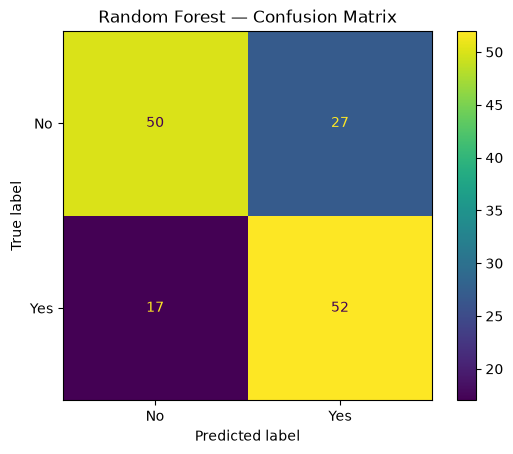

In [7]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=le_target.classes_)
plt.title("Random Forest — Confusion Matrix")
plt.show()

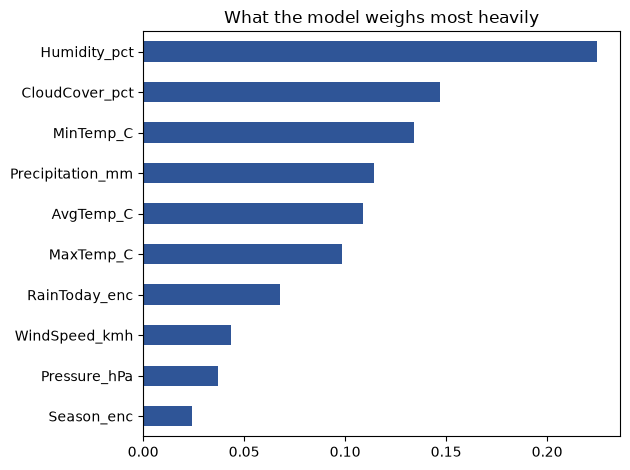

In [8]:
importances = pd.Series(model.feature_importances_, index=feature_cols).sort_values()
importances.plot(kind="barh", title="What the model weighs most heavily", color="#2F5597")
plt.tight_layout()
plt.show()

## 5. Save the model for the app

We bundle the trained model **and** the three label encoders **and** the feature column
order into one `.pkl` file. The Streamlit app just needs to load this one file — it doesn't
need to see the training data or retrain anything.

In [9]:
bundle = {
    "model": model,
    "le_season": le_season,
    "le_raintoday": le_raintoday,
    "le_target": le_target,
    "feature_cols": feature_cols,
}

joblib.dump(bundle, "rain_model.pkl")
print("Saved rain_model.pkl")

Saved rain_model.pkl


## 7. Sanity-check the saved model 

Quick smoke test that reloads `rain_model.pkl` fresh from disk and runs one prediction —
exactly what `app.py` will do — so you can confirm everything works *before* launching
Streamlit.

In [10]:
reloaded = joblib.load("rain_model.pkl")
sample = X_test.iloc[[0]]
pred = reloaded["model"].predict(sample)
label = reloaded["le_target"].inverse_transform(pred)[0]
proba = reloaded["model"].predict_proba(sample)[0]

print("Sample input:")
print(sample)
print(f"\nPredicted RainTomorrow: {label}")
print(f"Probabilities -> No: {proba[0]:.3f}, Yes: {proba[1]:.3f}")

Sample input:
    Season_enc  MinTemp_C  MaxTemp_C  AvgTemp_C  Humidity_pct  Pressure_hPa  \
70           1        8.4       20.2       14.2          78.1        1016.8   

    WindSpeed_kmh  CloudCover_pct  Precipitation_mm  RainToday_enc  
70           31.3            49.9               6.4              1  

Predicted RainTomorrow: Yes
Probabilities -> No: 0.353, Yes: 0.647
